# Tarea 5. Modelos lineales

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta cuarta tarea, tendrás la oportunidad de estimar una relación cúbica usando un modelo lineal Bayesiano. Para esto usarás los datos en `data/Howell1`, considerando personas de todas las edades.

Por favor, intenta ser lo más explícit@ posible, y en lo posible, apóyate de la escritura matemática con $\LaTeX$.

Recuerda además que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

___

## 1. 

Describir el modelo usando el lenguaje probabilístico visto en clase. Asegurarse, mediante una simulación predictiva previa que las previas son plausibles.

**Ayuda**. Estandarizar el peso antes.

El modelo queda de la siguiente manera 


\begin{align}
\begin{array}{lcl}
h_i & \sim & \text{Normal}(\mu_i, \sigma) \\
\mu_i & = & \alpha + \beta_1 w_{scaled,i} + \beta_2 w_{scaled,i}^2 + \beta_3 w_{scaled,i}^3 \\

w_{scaled,i} & = & \dfrac{w_i - \bar{w}}{s_w} \\

\alpha & \sim & \text{Normal}(140, 20) \\
\beta_1 & \sim & \text{Log-Normal}(0, 1) \\
\beta_2 & \sim & \text{Normal}(0, 5) \\
\beta_3 & \sim & \text{Normal}(0, 2) \\
\sigma & \sim & \text{Uniform}(0, 50)
\end{array}
\end{align}

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import pymc as pm
import arviz as az

In [90]:
height_data = pd.read_csv('data/Howell1.csv', sep=';')

In [91]:
# Previas
alpha = stats.norm(loc=150, scale=20)
beta1 = stats.lognorm(s=0.5, scale=np.exp(0))
beta2 = stats.norm(loc=0, scale=5)
beta3 = stats.norm(loc=0, scale=2)
sigma = stats.uniform(loc=0, scale=50)

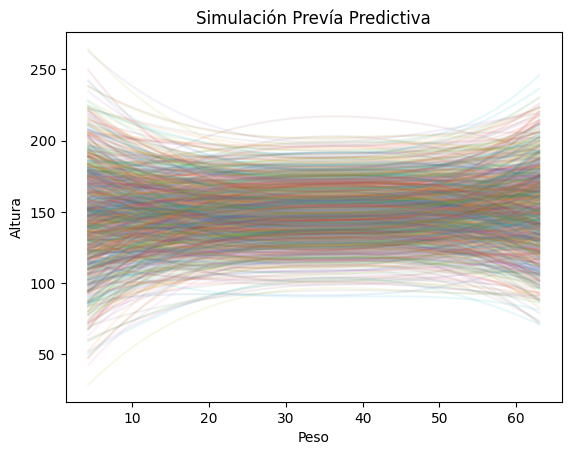

In [92]:
# Simulación previa predictiva

# Número de muestras
n_samples = 1000
# Vector de pesos (w)
w = height_data['weight'].values
w = sorted(w)  # Ordenar pesos para mejor visualización
# Peso promedio (w_bar)
w_bar = np.mean(w)
w_std = np.std(w)

w_standar = (w - w_bar) / w_std

# Muestras de alpha, betas y mu
alpha_samples = alpha.rvs(size=n_samples)
beta1_samples = beta1.rvs(size=n_samples)
beta2_samples = beta2.rvs(size=n_samples)
beta3_samples = beta3.rvs(size=n_samples)

mu_samples = (
    alpha_samples + beta1_samples * w_standar[:, np.newaxis] +
    beta2_samples * w_standar[:, np.newaxis]**2 + 
    beta3_samples * w_standar[:, np.newaxis]**3
    )


# Gráfico de muestras de mu vs peso
plt.plot(w, mu_samples, alpha=0.1)
plt.xlabel('Peso')
plt.ylabel('Altura')
plt.title('Simulación Prevía Predictiva')
plt.show()

## 2.

Encontrar la distribución posterior de los parámetros. ¿Qué puede concluir de cada uno de ellos?

In [93]:
w = height_data['weight'].values
h = height_data['height'].values

w_bar = np.mean(w)
w_std = np.std(w)

w_standar = (w - w_bar) / w_std

with pm.Model() as cubic_height_model:
    # Priors
    alpha = pm.Normal('alpha', mu=150, sigma=20)
    beta1 = pm.Lognormal('beta1', mu=0, sigma=1)
    beta2 = pm.Normal('beta2', mu=0, sigma=5)
    beta3 = pm.Normal('beta3', mu=0, sigma=2)
    sigma = pm.Uniform('sigma', lower=0, upper=50)
    # Mu
    mu = alpha + beta1 * w_standar + beta2 * (w_standar**2) + beta3 * (w_standar**3)
    # Likelihood
    height = pm.Normal('height', mu=mu, sigma=sigma, observed=h)
    # Muestreo
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.


In [94]:
# Distribución posterior de los parámetros
idata.posterior

<xarray.Dataset> Size: 168kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    alpha    (chain, draw) float64 32kB 146.7 147.0 146.7 ... 146.8 146.7 146.8
    beta2    (chain, draw) float64 32kB -6.646 -6.693 -6.584 ... -6.884 -6.478
    beta3    (chain, draw) float64 32kB 3.53 3.572 3.665 ... 3.052 3.382 3.871
    beta1    (chain, draw) float64 32kB 15.11 14.93 14.43 ... 15.92 15.02 14.53
    sigma    (chain, draw) float64 32kB 4.887 4.892 4.88 ... 4.776 4.891 4.741
Attributes:
    created_at:                 2026-04-30T05:04:36.686585+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              75.55579376220703
    tuning_steps:               1000

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'beta1'}>,
        <Axes: title={'center': 'beta2'}>],
       [<Axes: title={'center': 'beta3'}>,
        <Axes: title={'center': 'sigma'}>, <Axes: >]], dtype=object)

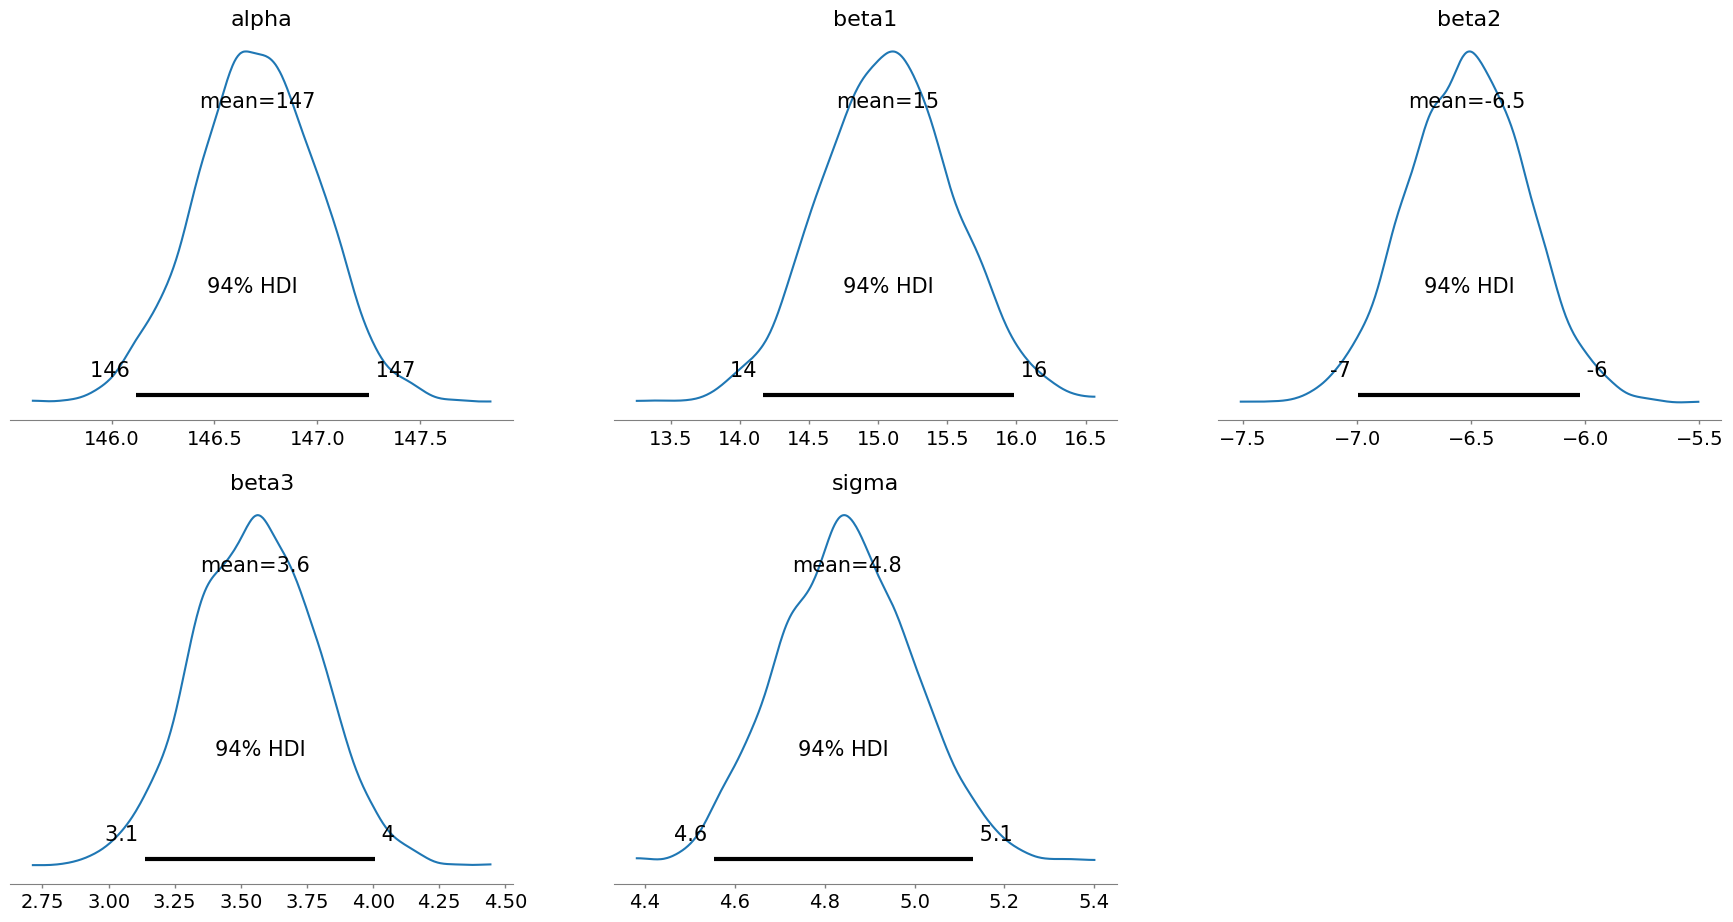

In [95]:
# az.plot_posterior
az.plot_posterior(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'sigma'])

In [96]:
alpha_bar = idata.posterior['alpha'].mean().values
beta1_bar = idata.posterior['beta1'].mean().values
beta2_bar = idata.posterior['beta2'].mean().values
beta3_bar = idata.posterior['beta3'].mean().values
alpha_bar, beta1_bar, beta2_bar, beta3_bar

(array(146.70692105),
 array(15.07044345),
 array(-6.51808465),
 array(3.55507213))

¿Qué podemos decir?

- La altura promedio, al peso promedio está alrededor de 146.71 cm.

- La $\beta_1$ no deci que por cada 1 desviacion estandar del peso se espera que la altura sea ~15 cm mayor.

- La $\beta_2$ salio negativa con un valor ~ -6.5 y esto nos dice que es una función concava hacia abajo, entonces mientras mas va aumentando el peso menor va siendo el cambio en la altura 

- La $\beta_3$ es de valor positivo con un valor ~ 3.55, podemos ver que tiener un valor mas pequeño en comparacion con los demas esto porque crece muy rapido porque es cubica, esta nos sirve para que en los valores por debajo de la media crezca rapido y despues de la media sigan creciendo pero no tanto, porque lo contraresta la $\beta_2$

## 3.

¿Cuál es la distribución de la altura promedio de un infante de 10kg según tu modelo y los datos?

In [97]:
alpha_samples = idata.posterior['alpha'].values.flatten()
beta1_samples = idata.posterior['beta1'].values.flatten()
beta2_samples = idata.posterior['beta2'].values.flatten()
beta3_samples = idata.posterior['beta3'].values.flatten()
sigma_samples = idata.posterior['sigma'].values.flatten()

In [98]:
# mu at 10
w_10 = (10 - w_bar) / w_std
mu_at_10 = (
    alpha_samples + 
    beta1_samples * w_10 +
    beta2_samples * w_10**2 +
    beta3_samples * w_10**3
)

<Axes: >

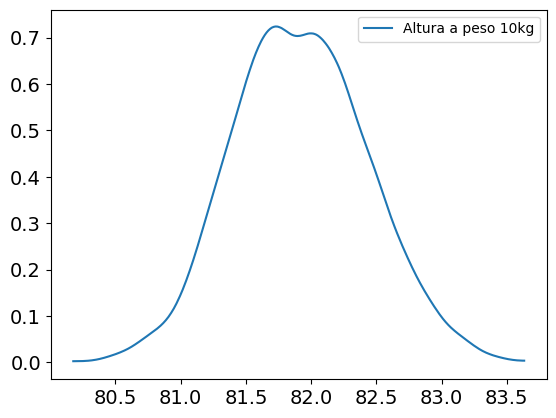

In [114]:
# kde plot
az.plot_kde(mu_at_10, label='Altura a peso 10kg')

In [115]:
# az.hdi
az.hdi(mu_at_10, hdi_prob=0.95)

array([80.98011797, 82.97036118])

La altura promedio está entre 80.98 cm y 82.97 cm, dado que el peso es 10 kg.

## 4.

Graficar:

- El intervalo de credibilidad al 89% de la altura para cada peso.
- El intervalo de credibilidad al 89% de la altura promedio para cada peso.
- La altura promedio para cada peso.
- Los puntos correspondientes a cada individuo.

In [111]:
w_plot = np.linspace(height_data['weight'].min(), height_data['weight'].max(), 544)
w_stan = (w_plot - w_bar) / w_std

mu_samples = (
    alpha_samples[:, np.newaxis] + 
    beta1_samples[:, np.newaxis] * w_stan + 
    beta2_samples[:, np.newaxis] * (w_stan**2) + 
    beta3_samples[:, np.newaxis] * (w_stan**3)
    )

h_pred = np.random.normal(loc=mu_samples, scale=sigma_samples[:, np.newaxis])


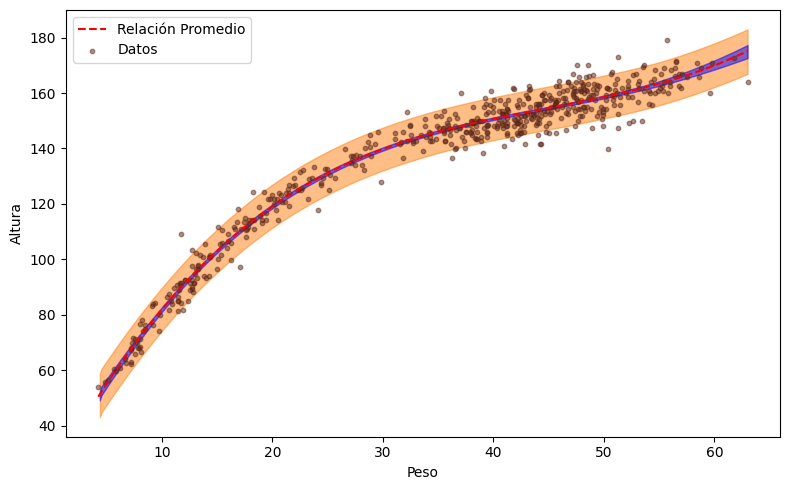

In [113]:
plt.figure(figsize=(8, 5))

# Intervalo de credibilidad de la altura
az.plot_hdi(w_plot, h_pred, hdi_prob=0.89)
# Intervalo de credibilidad de la altura promedio
az.plot_hdi(w_plot, mu_samples, color='blue', hdi_prob=0.89)
# Línea promedio
plt.plot(w_plot, mu_samples.mean(axis=0), '--r', label='Relación Promedio')
# Nube de puntos
plt.scatter(height_data['weight'], height_data['height'], label='Datos', color="#5C2719", alpha=0.5, s=10)
# Etiquetas
plt.xlabel('Peso')
plt.ylabel('Altura')
plt.legend()
plt.tight_layout()
plt.show()

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>